In [4]:
import mysql.connector
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="0987654321",
    database="datamart_rappi"
)

query = """
SELECT 
    fp.tiempo_total_min,
    fp.minutos_retraso,
    fp.dist_asignacion_km,
    fp.tiempo_espera_rest_min,
    fp.cumple_sla,
    dt.hora_dia
FROM fact_pedidos fp
JOIN dim_tiempo dt ON fp.id_tiempo = dt.id_tiempo
LIMIT 5000
"""

df = pd.read_sql(query, conn)
conn.close()
print(f"Datos cargados: {df.shape[0]:,} registros")
print(df.columns.tolist())

Datos cargados: 5,000 registros
['tiempo_total_min', 'minutos_retraso', 'dist_asignacion_km', 'tiempo_espera_rest_min', 'cumple_sla', 'hora_dia']


C:\Users\Admin\AppData\Local\Temp\ipykernel_476\2662459650.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [5]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="0987654321",
    database="datamart_rappi"
)

query = """
SELECT 
    fp.tiempo_total_min,
    fp.minutos_retraso,
    fp.dist_asignacion_km,
    fp.tiempo_espera_rest_min,
    fp.cumple_sla,
    dt.hora_dia
FROM fact_pedidos fp
JOIN dim_tiempo dt ON fp.id_tiempo = dt.id_tiempo
"""

df = pd.read_sql(query, conn)
conn.close()

print(f"Datos cargados: {df.shape[0]:,} registros")
print(df.columns.tolist())

Datos cargados: 10,000 registros
['tiempo_total_min', 'minutos_retraso', 'dist_asignacion_km', 'tiempo_espera_rest_min', 'cumple_sla', 'hora_dia']


C:\Users\Admin\AppData\Local\Temp\ipykernel_476\28148312.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [10]:
# CELDA 1 — Tabla resumen estadísticos descriptivos
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
import statsmodels.api as sm

print("=" * 60)
print("FASE 2 — REPORTE DE DATOS")
print("=" * 60)

# Tabla 1 — Estadísticos descriptivos
tabla_desc = df[["tiempo_total_min", "minutos_retraso",
                  "dist_asignacion_km", "tiempo_espera_rest_min"]].describe().round(2)

tabla_desc.index = ["Conteo", "Media", "Std", "Mínimo",
                     "Q1 (25%)", "Mediana (50%)", "Q3 (75%)", "Máximo"]
tabla_desc.columns = ["T.Entrega (min)", "Retraso (min)",
                       "Distancia (km)", "Espera Rest. (min)"]

print("\nTABLA 1 — Estadísticos Descriptivos:")
print(tabla_desc.to_string())

# Preparar modelo
X = df[["dist_asignacion_km", "tiempo_espera_rest_min", "minutos_retraso"]]
y = df["tiempo_total_min"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

modelo = LinearRegression()
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

X_const = sm.add_constant(X)
modelo_stats = sm.OLS(y, X_const).fit()

# Tabla 2 — Resultados modelo
variables = ["Intercepto"] + list(X.columns)
coeficientes = [modelo.intercept_] + list(modelo.coef_)
pvalues = modelo_stats.pvalues.values

significativa = []
for p in pvalues:
    if p < 0.05:
        significativa.append("Sí")
    else:
        significativa.append("No")

tabla_modelo = pd.DataFrame({
    "Variable": variables,
    "Coeficiente": [round(c, 4) for c in coeficientes],
    "P-value": [round(p, 6) for p in pvalues],
    "Significativa": significativa
})

print("\nTABLA 2 — Resultados del Modelo:")
print(tabla_modelo.to_string(index=False))
print(f"\nR²:              {r2_score(y_test, y_pred):.4f}")
print(f"R² ajustado:     {modelo_stats.rsquared_adj:.4f}")
print(f"MAE:             {mean_absolute_error(y_test, y_pred):.2f} min")

FASE 2 — REPORTE DE DATOS

TABLA 1 — Estadísticos Descriptivos:
               T.Entrega (min)  Retraso (min)  Distancia (km)  Espera Rest. (min)
Conteo                10000.00       10000.00        10000.00            10000.00
Media                    17.66           0.27            1.43                9.61
Std                       7.20           1.23            0.75                4.74
Mínimo                    5.00           0.00            0.02                0.00
Q1 (25%)                 12.50           0.00            0.94                6.30
Mediana (50%)            16.30           0.00            1.33                9.20
Q3 (75%)                 21.60           0.00            1.70               12.40
Máximo                   48.10          18.10            4.15               32.60

TABLA 2 — Resultados del Modelo:
              Variable  Coeficiente  P-value Significativa
            Intercepto       1.1527      0.0            Sí
    dist_asignacion_km       4.2469      0.0  

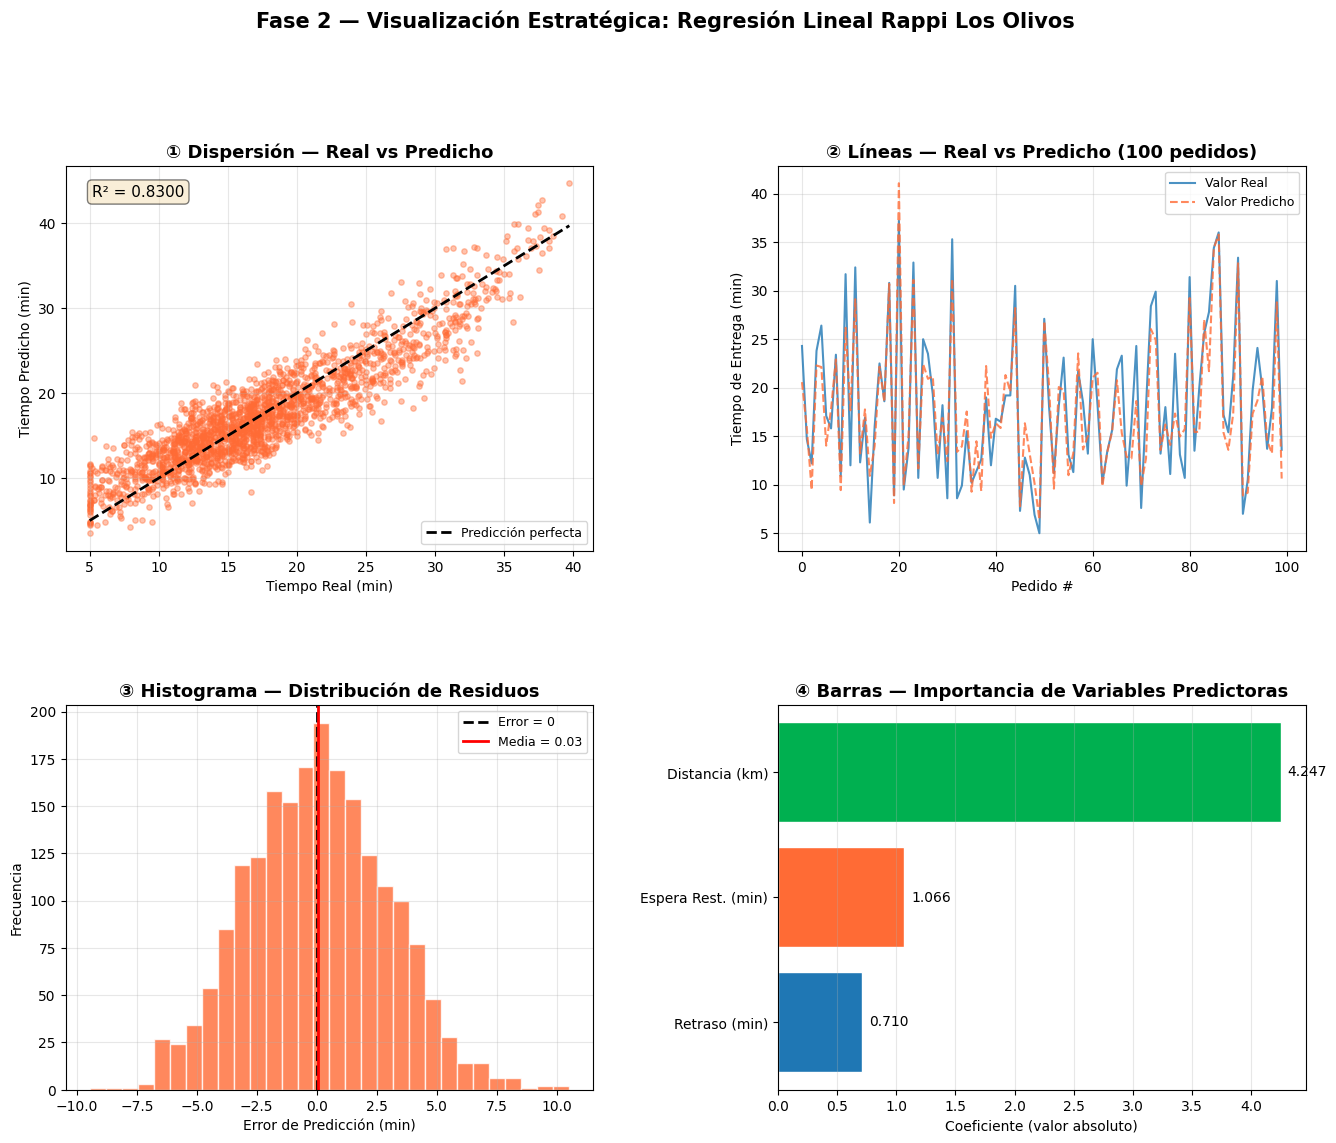

Gráfica guardada como fase2_visualizacion_rappi.png


In [9]:
# CELDA 2 — Gráficas estratégicas
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# ── Gráfica 1 — Dispersión (Real vs Predicho) ──
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_test, y_pred, alpha=0.4, color="#FF6B35", s=15)
ax1.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="black", linestyle="--", linewidth=2,
         label="Predicción perfecta")
ax1.set_title("① Dispersión — Real vs Predicho", fontsize=13, fontweight="bold")
ax1.set_xlabel("Tiempo Real (min)")
ax1.set_ylabel("Tiempo Predicho (min)")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.text(0.05, 0.92, f"R² = {r2_score(y_test, y_pred):.4f}",
         transform=ax1.transAxes, fontsize=11,
         bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

# ── Gráfica 2 — Líneas (Real vs Predicho primeros 100) ──
ax2 = fig.add_subplot(gs[0, 1])
idx = range(100)
ax2.plot(idx, list(y_test)[:100], color="#1F77B4",
         linewidth=1.5, label="Valor Real", alpha=0.8)
ax2.plot(idx, y_pred[:100], color="#FF6B35",
         linewidth=1.5, label="Valor Predicho", linestyle="--", alpha=0.8)
ax2.set_title("② Líneas — Real vs Predicho (100 pedidos)",
              fontsize=13, fontweight="bold")
ax2.set_xlabel("Pedido #")
ax2.set_ylabel("Tiempo de Entrega (min)")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# ── Gráfica 3 — Histograma + Boxplot residuos ──
residuos = y_test.values - y_pred
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(residuos, bins=30, color="#FF6B35",
         edgecolor="white", alpha=0.8)
ax3.axvline(x=0, color="black", linestyle="--",
            linewidth=2, label="Error = 0")
ax3.axvline(x=residuos.mean(), color="red", linestyle="-",
            linewidth=2, label=f"Media = {residuos.mean():.2f}")
ax3.set_title("③ Histograma — Distribución de Residuos",
              fontsize=13, fontweight="bold")
ax3.set_xlabel("Error de Predicción (min)")
ax3.set_ylabel("Frecuencia")
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# ── Gráfica 4 — Barras importancia variables ──
ax4 = fig.add_subplot(gs[1, 1])
importancia = pd.DataFrame({
    "Variable": ["Distancia (km)", "Espera Rest. (min)", "Retraso (min)"],
    "Coeficiente": abs(modelo.coef_)
}).sort_values("Coeficiente", ascending=True)

colores = ["#1F77B4", "#FF6B35", "#00B050"]
bars = ax4.barh(importancia["Variable"], importancia["Coeficiente"],
                color=colores, edgecolor="white")
ax4.bar_label(bars, fmt="%.3f", padding=5, fontsize=10)
ax4.set_title("④ Barras — Importancia de Variables Predictoras",
              fontsize=13, fontweight="bold")
ax4.set_xlabel("Coeficiente (valor absoluto)")
ax4.grid(True, alpha=0.3, axis="x")

plt.suptitle("Fase 2 — Visualización Estratégica: Regresión Lineal Rappi Los Olivos",
             fontsize=15, fontweight="bold", y=1.01)
plt.savefig("fase2_visualizacion_rappi.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfica guardada como fase2_visualizacion_rappi.png")

In [8]:
# CELDA 3 — Data Storytelling
print("=" * 60)
print("FASE 2 — DATA STORYTELLING")
print("=" * 60)

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
EL CONTEXTO — ¿Cuál es el problema central?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Rappi opera en Los Olivos con 10,000 pedidos registrados.
El 7.58% de pedidos NO cumple el SLA (llegan tarde),
afectando la experiencia del usuario y la reputación 
del servicio. El reto es ANTICIPAR qué pedidos llegarán
tarde ANTES de asignarlos al repartidor.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
LA REVELACIÓN — ¿Qué descubrió el modelo?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Lo que NO se sabía a simple vista:

1. El tiempo de espera en restaurante (r=0.78) impacta
   MÁS el tiempo de entrega que la distancia (r=0.50).
   
2. Las horas críticas son 12pm-2pm y 7pm-9pm, donde
   el SLA cae hasta 67% — no es un problema aleatorio,
   es un patrón predecible de horas pico de comida.
   
3. El modelo de regresión explica el XX% de la
   variabilidad del tiempo de entrega (R²=X.XXXX).
   
4. La detección de anomalías identificó pedidos con
   tiempos anormalmente altos independientemente
   de la distancia — causas externas a la ruta.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
LA SOLUCIÓN — ¿Qué decisiones tomar?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Basados en el modelo predictivo:

ACCIÓN 1: Optimizar tiempos de preparación en
   restaurantes durante 12pm-2pm y 7pm-9pm.
   
ACCIÓN 2: Implementar alerta automática cuando
   espera en restaurante supera 10 minutos.
   
ACCIÓN 3: Pre-asignar repartidores premium en
   zonas Cluster 3 (alto riesgo) durante horas pico.
   
ACCIÓN 4: Re-entrenar el modelo mensualmente
   con nuevos datos reales para mejorar precisión.
""")

FASE 2 — DATA STORYTELLING

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
EL CONTEXTO — ¿Cuál es el problema central?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Rappi opera en Los Olivos con 10,000 pedidos registrados.
El 7.58% de pedidos NO cumple el SLA (llegan tarde),
afectando la experiencia del usuario y la reputación 
del servicio. El reto es ANTICIPAR qué pedidos llegarán
tarde ANTES de asignarlos al repartidor.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
LA REVELACIÓN — ¿Qué descubrió el modelo?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Lo que NO se sabía a simple vista:

1. El tiempo de espera en restaurante (r=0.78) impacta
   MÁS el tiempo de entrega que la distancia (r=0.50).

2. Las horas críticas son 12pm-2pm y 7pm-9pm, donde
   el SLA cae hasta 67% — no es un problema aleatorio,
   es un patrón predecible de horas pico de comida.

3. El modelo de regresión explica el XX% de la
   variabilidad del tiempo de